# CIFAR-100 Batch Size Experiment Analysis

CIFAR-100 실험(`exp_outputs/CIFAR100/...`)과 baseline Full-FT(`exp_outputs/CIFAR100_FT/...`) 결과를 불러와 batch size 변화에 따른 학습/검증 추이를 시각화하고, 겹치는 배치 크기에서 두 방법을 오버레이로 비교합니다.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="colorblind")

EXPERIMENT_SPECS = {
    "GaLore": "exp_outputs/CIFAR100",
    "Full-FT": "exp_outputs/CIFAR100_FT",
}

METHOD_ORDER = ["GaLore", "Full-FT"]

METHOD_STYLE = {
    "GaLore": {"color": "#08519c", "linestyle": "-"},
    "Full-FT": {"color": "#d94801", "linestyle": "--"},
}


def resolve_path(rel_path: str) -> Path:
    candidates = [
        Path(rel_path),
        Path("..") / rel_path,
        Path("../..") / rel_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not locate {rel_path}. Update resolve_path().")


def parse_batch_size(folder_name: str) -> int:
    for part in folder_name.split("_"):
        if part.startswith("bs"):
            try:
                return int(part[2:])
            except ValueError:
                continue
    raise ValueError(f"Unable to parse batch size from {folder_name}")


def load_metrics(path: Path) -> Dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


summary_records: List[Dict[str, Any]] = []
metrics_cache: Dict[Tuple[str, int], Dict[str, Any]] = {}
method_batch_sizes: Dict[str, List[int]] = {}

for method in METHOD_ORDER:
    rel_path = EXPERIMENT_SPECS.get(method)
    if rel_path is None:
        continue
    try:
        method_root = resolve_path(rel_path)
    except FileNotFoundError as exc:
        print(f"Skipping {method}: {exc}")
        continue

    batch_dirs = sorted(
        [d for d in method_root.iterdir() if d.is_dir() and d.name.startswith("bs")],
        key=lambda d: parse_batch_size(d.name),
    )
    if not batch_dirs:
        print(f"No batch directories found for {method} at {method_root}")
        continue

    print(f"{method} root: {method_root}")
    collected_sizes: List[int] = []

    for folder in batch_dirs:
        bs = parse_batch_size(folder.name)
        metrics_path = folder / "metrics.json"
        if not metrics_path.exists():
            continue
        metrics = load_metrics(metrics_path)
        metrics_cache[(method, bs)] = metrics
        collected_sizes.append(bs)
        epoch_metrics = metrics.get("epoch_metrics", [])
        final_epoch = epoch_metrics[-1] if epoch_metrics else {}
        summary_records.append(
            {
                "method": method,
                "batch_size": bs,
                "folder": folder.name,
                "epochs_completed": len(epoch_metrics),
                "val_loss": final_epoch.get("val_loss"),
                "val_acc": final_epoch.get("val_acc"),
                "val_f1": final_epoch.get("val_f1"),
                "train_loss_last": final_epoch.get("train_loss"),
                "train_acc_last": final_epoch.get("train_acc"),
            }
        )

    if not collected_sizes:
        print(f"No metrics.json files found for {method} at {method_root}")
        continue

    method_batch_sizes[method] = sorted(set(collected_sizes))
    print(f"  batch sizes: {method_batch_sizes[method]}")

valid_sets = [set(sizes) for sizes in method_batch_sizes.values() if sizes]
if not valid_sets:
    overlay_batch_sizes = []
elif len(valid_sets) == 1:
    overlay_batch_sizes = sorted(valid_sets[0])
else:
    overlay_batch_sizes = sorted(set.intersection(*valid_sets))

print(f"Batch sizes per method: {method_batch_sizes}")
if overlay_batch_sizes:
    print(f"Batch sizes with complete coverage: {overlay_batch_sizes}")
else:
    print("No overlapping batch sizes across methods; overlay plots will be skipped.")

summary_df = (
    pd.DataFrame(summary_records)
    .sort_values(["batch_size", "method"])
    .reset_index(drop=True)
)
summary_df

GaLore root: /workspace/joel/GaLore_YOWHAJNG/exp_outputs/CIFAR100
  batch sizes: [1, 8, 16, 32, 64, 128]
Full-FT root: /workspace/joel/GaLore_YOWHAJNG/exp_outputs/CIFAR100_FT
  batch sizes: [1, 8, 16, 32, 64, 128]
Full-FT root: /workspace/joel/GaLore_YOWHAJNG/exp_outputs/CIFAR100_FT
  batch sizes: [8, 16, 32, 64, 128]
Batch sizes per method: {'GaLore': [1, 8, 16, 32, 64, 128], 'Full-FT': [8, 16, 32, 64, 128]}
Batch sizes with complete coverage: [8, 16, 32, 64, 128]
  batch sizes: [8, 16, 32, 64, 128]
Batch sizes per method: {'GaLore': [1, 8, 16, 32, 64, 128], 'Full-FT': [8, 16, 32, 64, 128]}
Batch sizes with complete coverage: [8, 16, 32, 64, 128]


,method,batch_size,folder,epochs_completed,val_loss,val_acc,val_f1,train_loss_last,train_acc_last
0,GaLore,1,bs1_acc1_epochs30,30,0.319331,0.9085,0.908647,0.461413,0.87464
1,Full-FT,8,bs8_acc1_epochs30,30,0.406084,0.9115,0.911603,0.210658,0.94454
2,GaLore,8,bs8_acc1_epochs30,30,0.247086,0.9257,0.925771,0.457518,0.87428
3,Full-FT,16,bs16_acc1_epochs30,30,0.378670,0.9165,0.916674,0.226021,0.94014
4,GaLore,16,bs16_acc1_epochs30,30,0.238552,0.9281,0.928155,0.478990,0.86748
5,Full-FT,32,bs32_acc1_epochs30,30,0.331058,0.9227,0.922903,0.243194,0.93610
6,GaLore,32,bs32_acc1_epochs30,30,0.240884,0.9280,0.927891,0.507114,0.86048
7,Full-FT,64,bs64_acc1_epochs30,30,0.304302,0.9266,0.926740,0.263962,0.93108
8,GaLore,64,bs64_acc1_epochs30,30,0.245588,0.9259,0.925879,0.537426,0.85366
9,Full-FT,128,bs128_acc1_epochs30,10,0.284697,0.9231,0.923406,0.469127,0.88188


## 2. Parse Training Metrics per Batch Size
각 `metrics.json`의 `train_loss_per_iteration`을 펼쳐 step·epoch·loss DataFrame을 구성하고 smoothing/epoch marker 정보를 준비합니다.

In [2]:
train_rows: List[Dict[str, Any]] = []
for (method, bs), metrics in metrics_cache.items():
    for row in metrics.get("train_loss_per_iteration", []):
        train_rows.append(
            {
                "method": method,
                "batch_size": bs,
                "step": int(row.get("step", 0)),
                "epoch": float(row.get("epoch", 0.0)),
                "loss": float(row.get("loss", np.nan)),
            }
        )

train_df = (
    pd.DataFrame(train_rows)
    .sort_values(["method", "batch_size", "step"])
    .reset_index(drop=True)
)

if not train_df.empty:
    def ewm_span(series: pd.Series) -> pd.Series:
        span = max(50, int(len(series) * 0.01))
        return series.ewm(span=span, min_periods=1).mean()

    train_df["loss_smooth"] = (
        train_df.groupby(["method", "batch_size"])["loss"].transform(ewm_span)
    )
    epoch_markers = (
        train_df.assign(epoch_int=lambda df: df["epoch"].astype(int))
        .groupby(["method", "batch_size", "epoch_int"], as_index=False)["step"].min()
        .rename(columns={"epoch_int": "epoch"})
    )
    display(train_df.head())
    print(
        "Loaded {:,} train steps across {} methods / {} batch sizes.".format(
            len(train_df), train_df["method"].nunique(), train_df["batch_size"].nunique()
        )
    )
else:
    epoch_markers = pd.DataFrame(columns=["method", "batch_size", "epoch", "step"])
    print("No train step data found.")

,method,batch_size,step,epoch,loss,loss_smooth
0,Full-FT,8,0,1.0,4.643610,4.643610
1,Full-FT,8,1,1.0,4.642606,4.643108
2,Full-FT,8,2,1.0,4.585522,4.623892
3,Full-FT,8,3,1.0,4.587609,4.614807
4,Full-FT,8,4,1.0,4.669702,4.625809


Loaded 2,218,840 train steps across 2 methods / 6 batch sizes.


## 3. Plot Step-wise Train Loss with Trendline and Epoch Markers
각 batch size별 step-loss 곡선을 그리고 EWMA 추세선과 epoch 경계를 함께 나타냅니다.

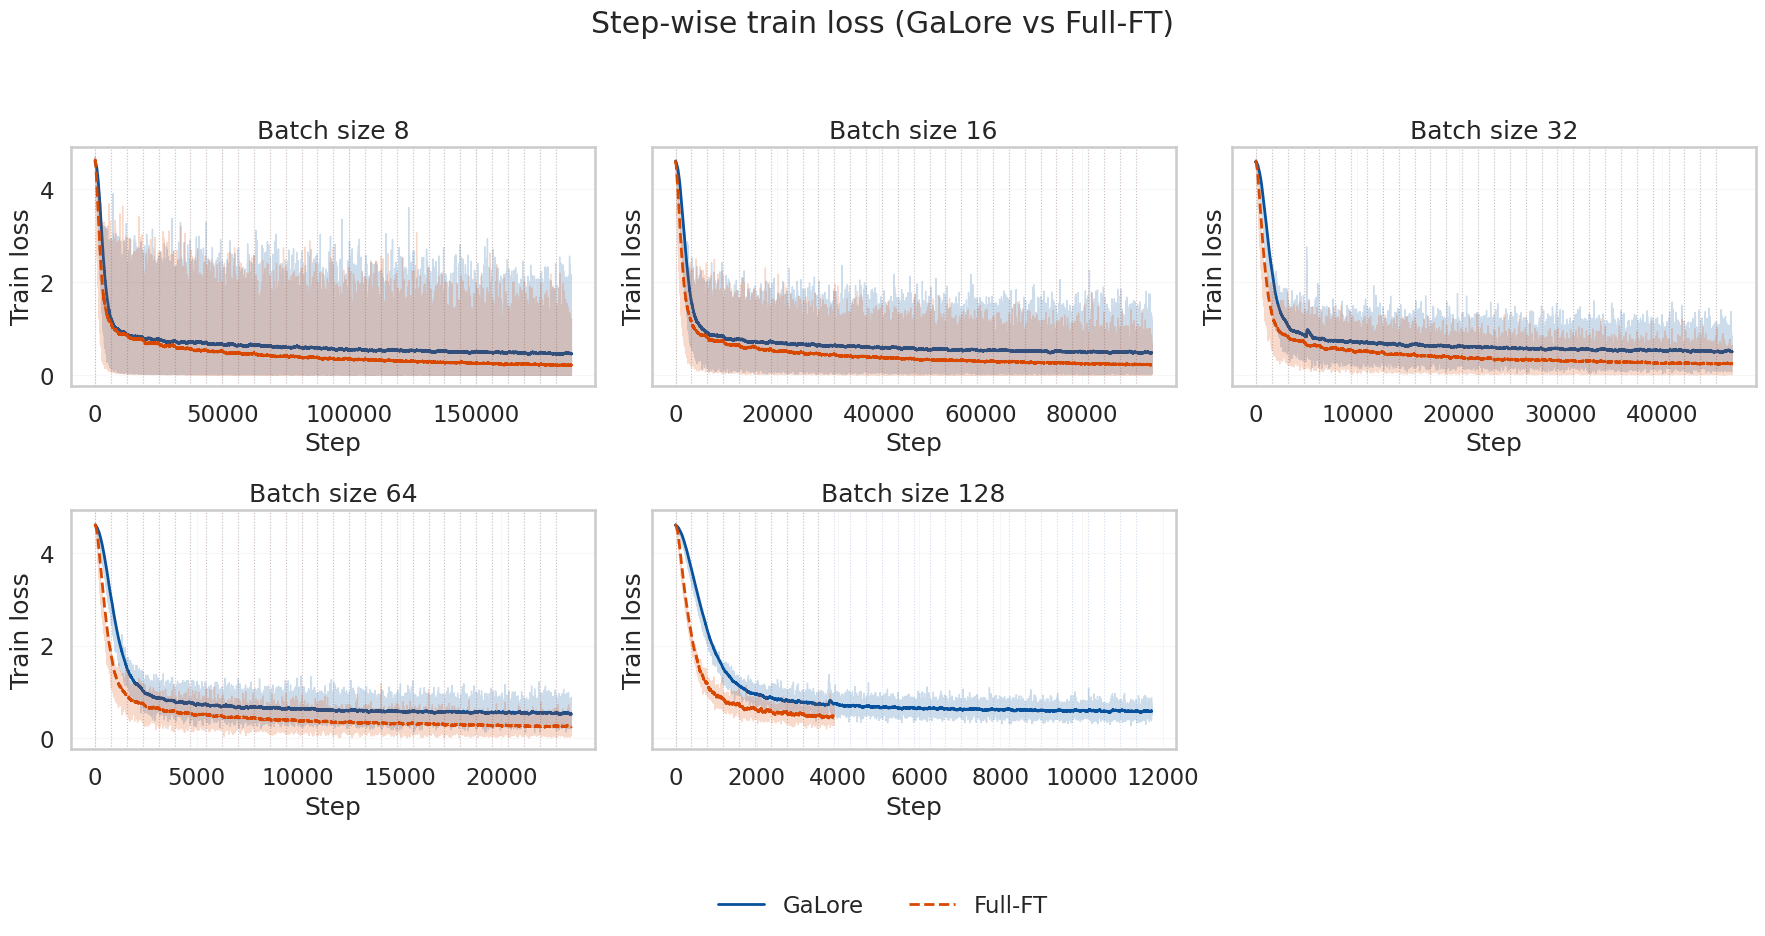

In [3]:
if train_df.empty:
    print("Training dataframe empty; skipping plot.")
else:
    methods_with_data = [m for m in METHOD_ORDER if m in method_batch_sizes]
    if len(methods_with_data) >= 2:
        plot_batch_sizes = [
            bs for bs in overlay_batch_sizes if bs in train_df["batch_size"].unique()
        ]
        if not plot_batch_sizes:
            print("No overlapping batch sizes with complete train data; skipping overlay plot.")
        else:
            n_cols = min(3, len(plot_batch_sizes))
            n_rows = math.ceil(len(plot_batch_sizes) / n_cols)
            fig, axes = plt.subplots(
                n_rows,
                n_cols,
                figsize=(6 * n_cols, 4.5 * n_rows),
                sharey=True,
            )
            if not isinstance(axes, np.ndarray):
                axes = np.array([axes])
            axes = axes.flatten()

            for ax, bs in zip(axes, plot_batch_sizes):
                ax.set_title(f"Batch size {bs}")
                for method in methods_with_data:
                    sub = train_df[
                        (train_df["method"] == method) & (train_df["batch_size"] == bs)
                    ]
                    if sub.empty:
                        continue
                    style = METHOD_STYLE.get(method, {})
                    color = style.get("color", None)
                    linestyle = style.get("linestyle", "-")
                    ax.plot(sub["step"], sub["loss"], color=color, alpha=0.2, linewidth=1)
                    ax.plot(
                        sub["step"],
                        sub["loss_smooth"],
                        color=color,
                        linestyle=linestyle,
                        linewidth=2,
                        label=f"{method} (EWMA)",
                    )
                    markers = epoch_markers[
                        (epoch_markers["method"] == method)
                        & (epoch_markers["batch_size"] == bs)
                    ]
                    for _, marker in markers.iterrows():
                        ax.axvline(
                            marker["step"],
                            color=color,
                            linestyle=":",
                            linewidth=0.8,
                            alpha=0.2,
                        )
                ax.set_xlabel("Step")
                ax.set_ylabel("Train loss")
                ax.grid(True, linewidth=0.4, alpha=0.3)

            for ax in axes[len(plot_batch_sizes):]:
                ax.axis("off")

            legend_handles = [
                Line2D(
                    [0],
                    [0],
                    color=METHOD_STYLE[m]["color"],
                    linestyle=METHOD_STYLE[m]["linestyle"],
                    linewidth=2,
                    label=m,
                )
                for m in methods_with_data
            ]
            fig.legend(
                legend_handles,
                [h.get_label() for h in legend_handles],
                loc="upper center",
                ncol=len(legend_handles),
                frameon=False,
                bbox_to_anchor=(0.5, 0.02),
            )
            fig.suptitle("Step-wise train loss (GaLore vs Full-FT)", y=0.98)
            fig.tight_layout(rect=[0, 0.05, 1, 0.95])
            plt.show()
    else:
        print("Only one method available; falling back to single-method plot without overlays.")
        batch_sizes = sorted(train_df["batch_size"].unique())
        n_cols = min(3, len(batch_sizes)) or 1
        n_rows = math.ceil(len(batch_sizes) / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharey=True)
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        axes = axes.flatten()
        for ax, bs in zip(axes, batch_sizes):
            sub = train_df[train_df["batch_size"] == bs]
            ax.plot(sub["step"], sub["loss"], color="#9ecae1", alpha=0.35, label="train loss")
            ax.plot(sub["step"], sub["loss_smooth"], color="#08519c", linewidth=2, label="EWMA")
            ax.set_title(f"Batch size {bs}")
            ax.set_xlabel("Step")
            ax.set_ylabel("Train loss")
            ax.grid(True, linewidth=0.4, alpha=0.3)
        for ax in axes[len(batch_sizes):]:
            ax.axis("off")
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.02))
        fig.suptitle("Step-wise train loss (single method)", y=0.98)
        fig.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()

## 4. Plot Validation Metrics per Epoch
`epoch_metrics`에서 epoch별 val loss/acc/f1을 추출하여 비교합니다.

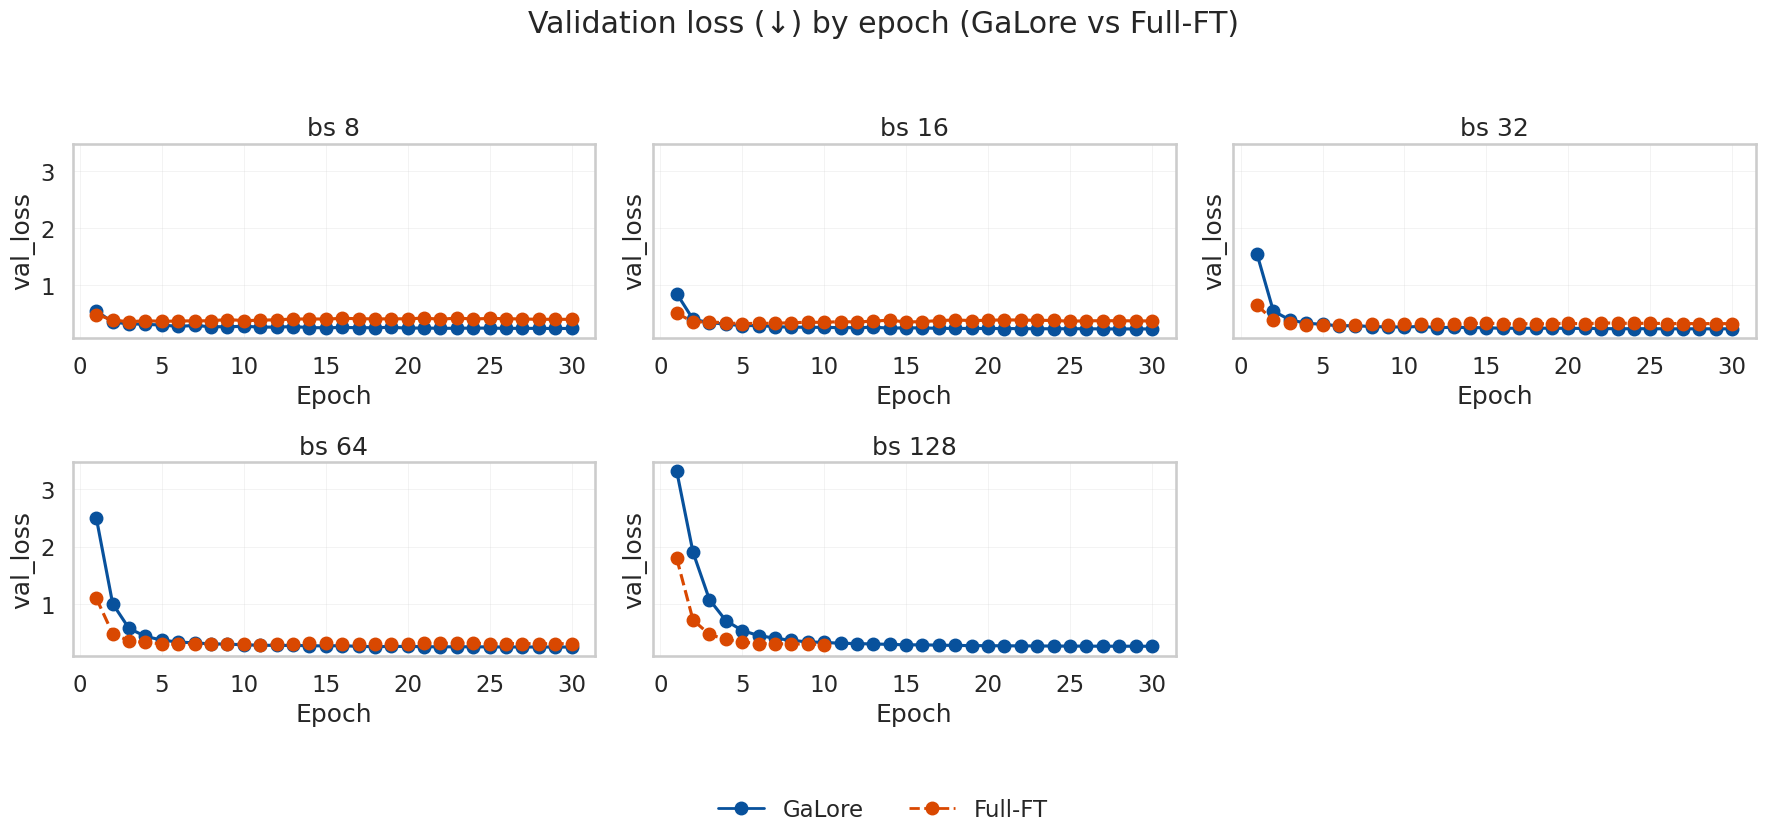

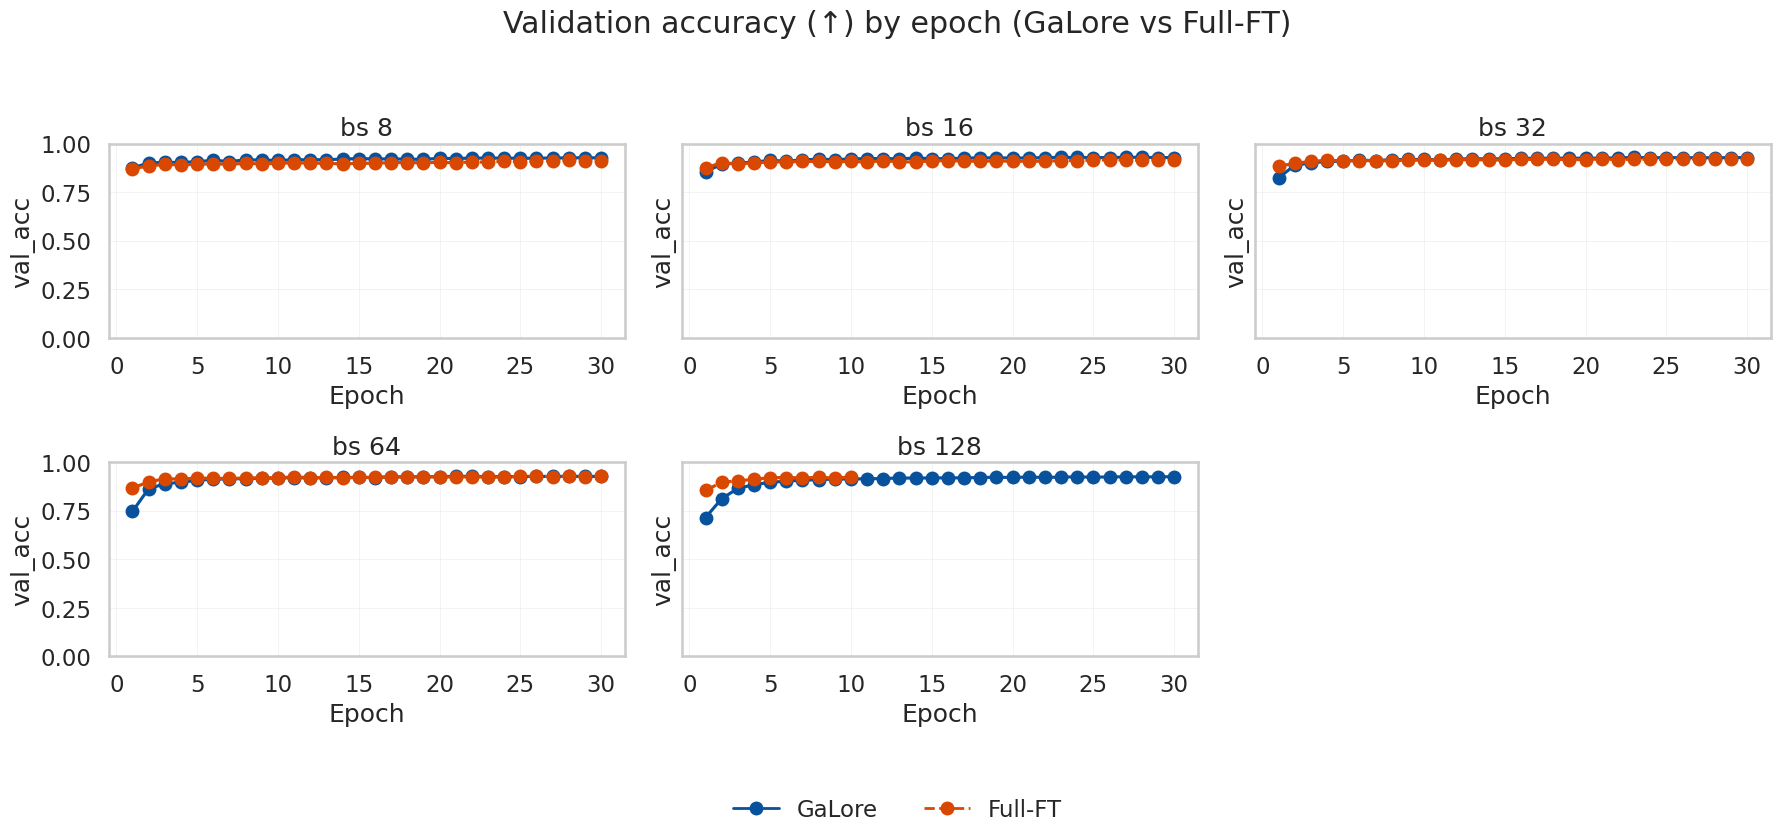

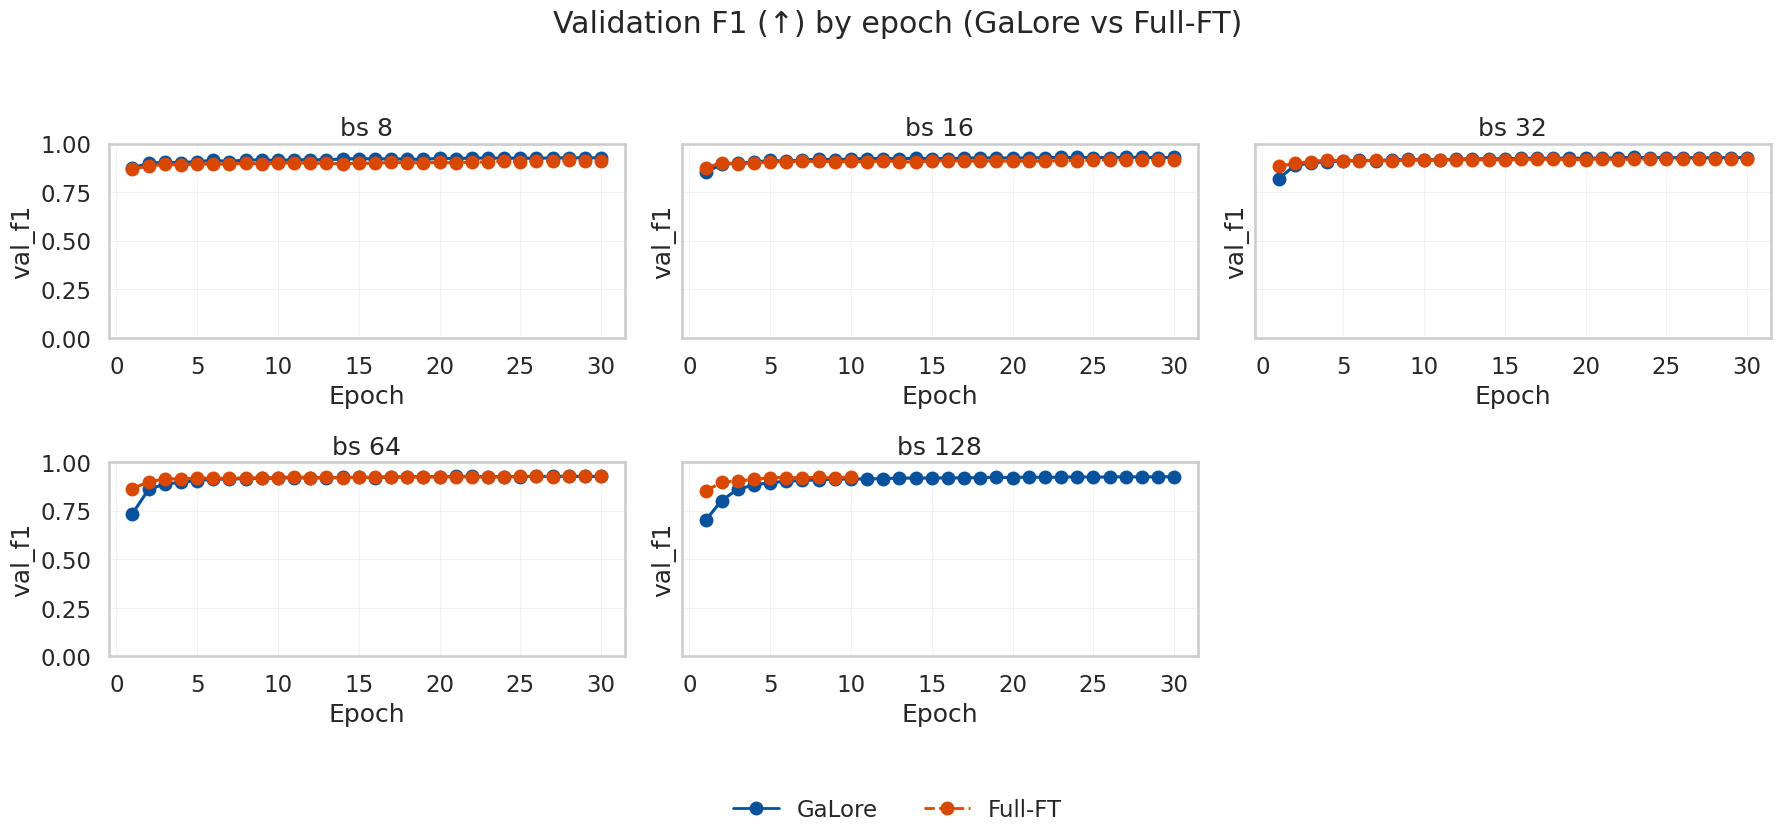

,method,batch_size,epoch,train_loss,train_acc,val_loss,val_acc,val_f1
305,GaLore,128,26,0.600177,0.83832,0.261617,0.9235,0.923396
306,GaLore,128,27,0.596275,0.83918,0.260391,0.9240,0.923921
307,GaLore,128,28,0.591059,0.84094,0.260429,0.9237,0.923598
308,GaLore,128,29,0.591060,0.84090,0.259899,0.9239,0.923793
309,GaLore,128,30,0.584608,0.84104,0.259434,0.9246,0.924488


In [4]:
epoch_rows: List[Dict[str, Any]] = []
for (method, bs), metrics in metrics_cache.items():
    for row in metrics.get("epoch_metrics", []):
        epoch_rows.append(
            {
                "method": method,
                "batch_size": bs,
                "epoch": int(row.get("epoch", 0)),
                "train_loss": float(row.get("train_loss", np.nan)),
                "train_acc": float(row.get("train_acc", np.nan)),
                "val_loss": float(row.get("val_loss", np.nan)),
                "val_acc": float(row.get("val_acc", np.nan)),
                "val_f1": float(row.get("val_f1", np.nan)),
            }
        )

epoch_df = (
    pd.DataFrame(epoch_rows)
    .sort_values(["method", "batch_size", "epoch"])
    .reset_index(drop=True)
)

if epoch_df.empty:
    print("No epoch metrics available.")
else:
    methods_with_data = [m for m in METHOD_ORDER if m in method_batch_sizes]
    if len(methods_with_data) >= 2:
        plot_batch_sizes = [
            bs for bs in overlay_batch_sizes if bs in epoch_df["batch_size"].unique()
        ]
        if not plot_batch_sizes:
            print("No overlapping batch sizes with epoch metrics; skipping overlay plots.")
        else:
            metrics_to_plot = [
                ("val_loss", "Validation loss (↓)", None),
                ("val_acc", "Validation accuracy (↑)", (0.0, 1.0)),
                ("val_f1", "Validation F1 (↑)", (0.0, 1.0)),
            ]
            for metric, title, ylim in metrics_to_plot:
                n_cols = min(3, len(plot_batch_sizes))
                n_rows = math.ceil(len(plot_batch_sizes) / n_cols)
                fig, axes = plt.subplots(
                    n_rows,
                    n_cols,
                    figsize=(6 * n_cols, 4 * n_rows),
                    sharey=True,
                )
                if not isinstance(axes, np.ndarray):
                    axes = np.array([axes])
                axes = axes.flatten()

                for ax, bs in zip(axes, plot_batch_sizes):
                    ax.set_title(f"bs {bs}")
                    for method in methods_with_data:
                        sub = epoch_df[
                            (epoch_df["method"] == method)
                            & (epoch_df["batch_size"] == bs)
                        ]
                        if sub.empty:
                            continue
                        style = METHOD_STYLE.get(method, {})
                        color = style.get("color")
                        linestyle = style.get("linestyle", "-")
                        ax.plot(
                            sub["epoch"],
                            sub[metric],
                            color=color,
                            linestyle=linestyle,
                            marker="o",
                            label=method,
                        )
                    ax.set_xlabel("Epoch")
                    ax.set_ylabel(metric)
                    if ylim:
                        ax.set_ylim(*ylim)
                    ax.grid(True, linewidth=0.4, alpha=0.4)
                for ax in axes[len(plot_batch_sizes):]:
                    ax.axis("off")
                legend_handles = [
                    Line2D(
                        [0],
                        [0],
                        color=METHOD_STYLE[m]["color"],
                        linestyle=METHOD_STYLE[m]["linestyle"],
                        linewidth=2,
                        marker="o",
                        label=m,
                    )
                    for m in methods_with_data
                ]
                fig.legend(
                    legend_handles,
                    [h.get_label() for h in legend_handles],
                    loc="upper center",
                    ncol=len(legend_handles),
                    frameon=False,
                    bbox_to_anchor=(0.5, 0.02),
                )
                fig.suptitle(f"{title} by epoch (GaLore vs Full-FT)", y=0.98)
                fig.tight_layout(rect=[0, 0.05, 1, 0.95])
                plt.show()
    else:
        print("Only one method available; showing aggregate validation curves.")
        fig, (ax_loss, ax_scores) = plt.subplots(1, 2, figsize=(18, 6))
        sns.lineplot(data=epoch_df, x="epoch", y="val_loss", hue="batch_size", marker="o", ax=ax_loss)
        ax_loss.set_title("Validation loss per epoch")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Val loss")
        ax_loss.grid(True, linewidth=0.4, alpha=0.4)
        ax_loss.legend(title="Batch size", loc="upper left", bbox_to_anchor=(1.02, 1))

        long_scores = epoch_df.melt(
            id_vars=["batch_size", "epoch"],
            value_vars=["val_acc", "val_f1"],
            var_name="metric",
            value_name="value",
        )
        sns.lineplot(
            data=long_scores,
            x="epoch",
            y="value",
            hue="batch_size",
            style="metric",
            markers=True,
            dashes=True,
            ax=ax_scores,
        )
        ax_scores.set_title("Validation accuracy / F1 per epoch")
        ax_scores.set_xlabel("Epoch")
        ax_scores.set_ylabel("Score")
        ax_scores.set_ylim(0.0, 1.0)
        ax_scores.grid(True, linewidth=0.4, alpha=0.4)
        ax_scores.legend(title="Batch / Metric", loc="upper left", bbox_to_anchor=(1.02, 1))
        fig.suptitle("CIFAR-100 validation metrics over epochs", y=0.98)
        fig.tight_layout(rect=[0, 0, 0.88, 0.95])
        plt.show()

    display(epoch_df.tail())

## 5. Aggregate Final Eval Scores Across Batch Sizes
각 batch size별 최종 validation accuracy/F1을 표로 요약합니다.

In [5]:
if summary_df.empty:
    print("Summary dataframe empty.")
else:
    summary_table = summary_df[
        ["method", "batch_size", "val_acc", "val_f1", "val_loss"]
    ].sort_values(["method", "batch_size"])
    display(
        summary_table.style.format(
            {
                "val_acc": "{:.4f}",
                "val_f1": "{:.4f}",
                "val_loss": "{:.4f}",
            }
        ).set_caption("Final validation metrics per method & batch size")
    )

    best_acc = (
        summary_table.loc[summary_table.groupby("method")["val_acc"].idxmax()]
        if not summary_table.empty
        else pd.DataFrame()
    )
    best_f1 = (
        summary_table.loc[summary_table.groupby("method")["val_f1"].idxmax()]
        if not summary_table.empty
        else pd.DataFrame()
    )
    if not best_acc.empty:
        for _, row in best_acc.iterrows():
            print(
                f"[{row['method']}] Highest accuracy batch size: {int(row['batch_size'])} ({row['val_acc']:.4f})"
            )
    if not best_f1.empty:
        for _, row in best_f1.iterrows():
            print(
                f"[{row['method']}] Highest F1 batch size: {int(row['batch_size'])} ({row['val_f1']:.4f})"
            )

,method,batch_size,val_acc,val_f1,val_loss
1,Full-FT,8,0.9115,0.9116,0.4061
3,Full-FT,16,0.9165,0.9167,0.3787
5,Full-FT,32,0.9227,0.9229,0.3311
7,Full-FT,64,0.9266,0.9267,0.3043
9,Full-FT,128,0.9231,0.9234,0.2847
0,GaLore,1,0.9085,0.9086,0.3193
2,GaLore,8,0.9257,0.9258,0.2471
4,GaLore,16,0.9281,0.9282,0.2386
6,GaLore,32,0.9280,0.9279,0.2409
8,GaLore,64,0.9259,0.9259,0.2456


[Full-FT] Highest accuracy batch size: 64 (0.9266)
[GaLore] Highest accuracy batch size: 16 (0.9281)
[Full-FT] Highest F1 batch size: 64 (0.9267)
[GaLore] Highest F1 batch size: 16 (0.9282)


## 6. Visualize Eval Accuracy and F1 Across Batch Sizes
최종 accuracy/F1을 동시에 보여주는 막대 그래프를 생성합니다.

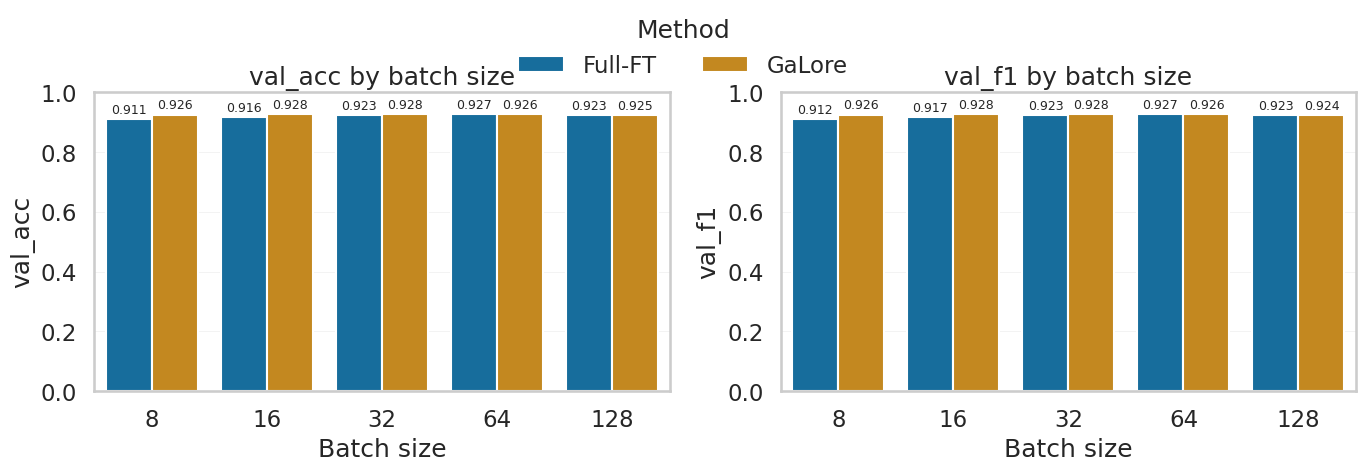

In [8]:
if summary_df.empty:
    print("No data to visualize.")
else:
    metrics_to_plot = ["val_acc", "val_f1"]
    plot_batch_sizes = overlay_batch_sizes if overlay_batch_sizes else sorted(summary_df["batch_size"].unique())
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(7 * len(metrics_to_plot), 5), sharey=False)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    legend_handles = legend_labels = None

    for ax, metric in zip(axes, metrics_to_plot):
        bar_df = summary_df[
            summary_df["batch_size"].isin(plot_batch_sizes)
        ][["method", "batch_size", metric]]
        sns.barplot(data=bar_df, x="batch_size", y=metric, hue="method", ax=ax)
        for container in ax.containers:
            labels = [f"{bar.get_height():.3f}" for bar in container]
            ax.bar_label(container, labels=labels, label_type="edge", padding=2, fontsize=9)
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
        ax.set_title(f"{metric} by batch size")
        ax.set_xlabel("Batch size")
        ax.set_ylabel(metric)
        if metric != "val_loss":
            ax.set_ylim(0.0, 1.0)
        ax.grid(True, axis="y", linewidth=0.4, alpha=0.4)

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Method",
            loc="upper center",
            ncol=len(legend_handles),
            frameon=False,
            bbox_to_anchor=(0.5, 0.98),
        )

    # fig.suptitle("Final CIFAR-100 validation accuracy / F1 by batch size", y=0.92)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

### Usage Notes
- 새로운 실험이 `exp_outputs/CIFAR100` 또는 `exp_outputs/CIFAR100_FT`에 추가되면 1–2번 셀만 다시 실행해 나머지 셀을 업데이트하세요.
- 다른 경로 구조를 사용할 경우 1번 셀의 `EXPERIMENT_SPECS`나 `resolve_path()` 후보 경로를 수정하면 됩니다.
- smoothing 강도를 바꾸고 싶다면 2번 셀의 `ewm_span` 함수에서 `span` 계산식을 조정하세요.
- Full-FT 대비 GaLore만 비교하고 싶으면 `METHOD_ORDER` 혹은 `EXPERIMENT_SPECS`에서 불필요한 엔트리를 제거하세요.